In [1]:
import plotly

print("Plotly version:", plotly.__version__)

Plotly version: 6.8.0


In [14]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [15]:
df = pd.read_csv("cleaned_data.csv", parse_dates=["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [16]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("Shape :", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nData Types\n")
print(df.dtypes)

DATASET OVERVIEW
Shape : (779425, 13)

Columns:

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour'],
      dtype='object')

Data Types

Invoice                 int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
Revenue               float64
Year                    int64
Month                  object
Day                    object
Hour                    int64
dtype: object


In [17]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
Year           0
Month          0
Day            0
Hour           0
dtype: int64

In [18]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
count,779425.000000,779425,779425,779425.000000,779425,779425.000000,779425.000000,779425,779425.000000,779425.000000,779425,779425,779425.000000
unique,NaN,4631,5283,NaN,NaN,NaN,NaN,41,NaN,NaN,12,7,NaN
top,NaN,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,NaN,November,Thursday,NaN
freq,NaN,5023,5016,NaN,NaN,NaN,NaN,700388,NaN,NaN,122073,155986,NaN
mean,537426.828586,NaN,NaN,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,NaN,22.291823,2010.432051,NaN,NaN,12.791884
min,489434.000000,NaN,NaN,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,NaN,0.001000,2009.000000,NaN,NaN,6.000000
25%,514483.000000,NaN,NaN,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,NaN,4.950000,2010.000000,NaN,NaN,11.000000
50%,536754.000000,NaN,NaN,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,NaN,12.480000,2010.000000,NaN,NaN,13.000000
75%,561995.000000,NaN,NaN,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,NaN,19.800000,2011.000000,NaN,NaN,14.000000
max,581587.000000,NaN,NaN,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,NaN,168469.600000,2011.000000,NaN,NaN,20.000000


In [19]:
total_revenue = df["Revenue"].sum()

customers = df["Customer ID"].nunique()

orders = df["Invoice"].nunique()

products = df["StockCode"].nunique()

countries = df["Country"].nunique()

avg_order = (
    df.groupby("Invoice")["Revenue"]
      .sum()
      .mean()
)

print("Total Revenue :",round(total_revenue,2))
print("Customers :",customers)
print("Orders :",orders)
print("Products :",products)
print("Countries :",countries)
print("Average Order Value :",round(avg_order,2))

Total Revenue : 17374804.27
Customers : 5878
Orders : 36969
Products : 4631
Countries : 41
Average Order Value : 469.98


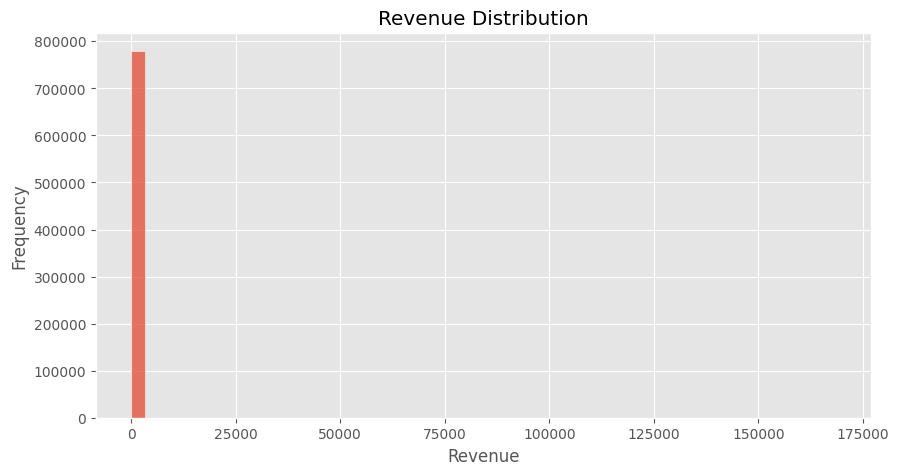

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df["Revenue"],bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

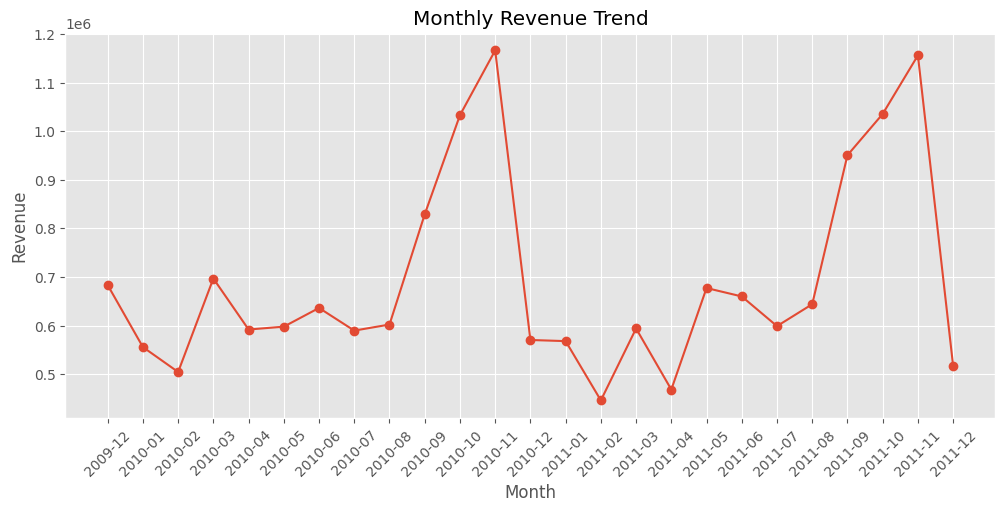

In [21]:
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

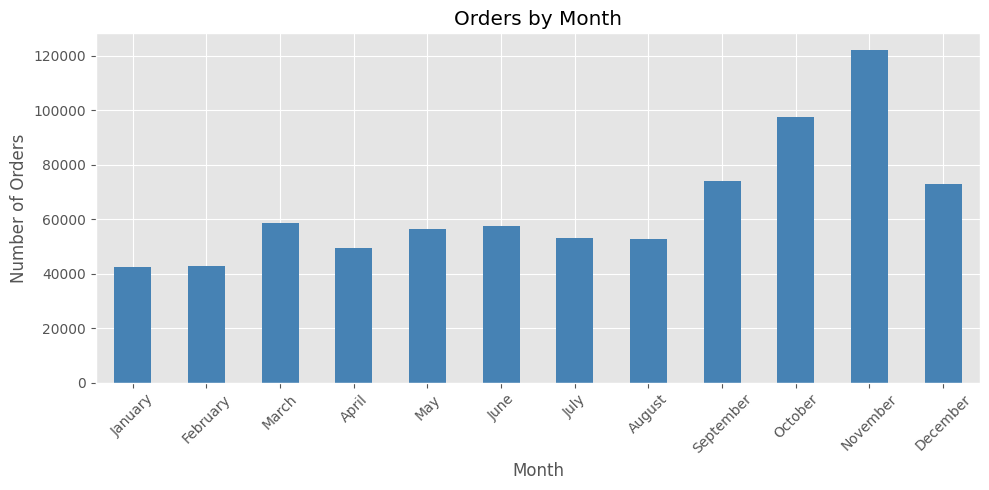

In [22]:
# Orders by Month

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_orders = (
    df.groupby("Month")["Invoice"]
      .count()
      .reindex(month_order)
      .dropna()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(kind="bar", color="steelblue")

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [23]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'Hour']


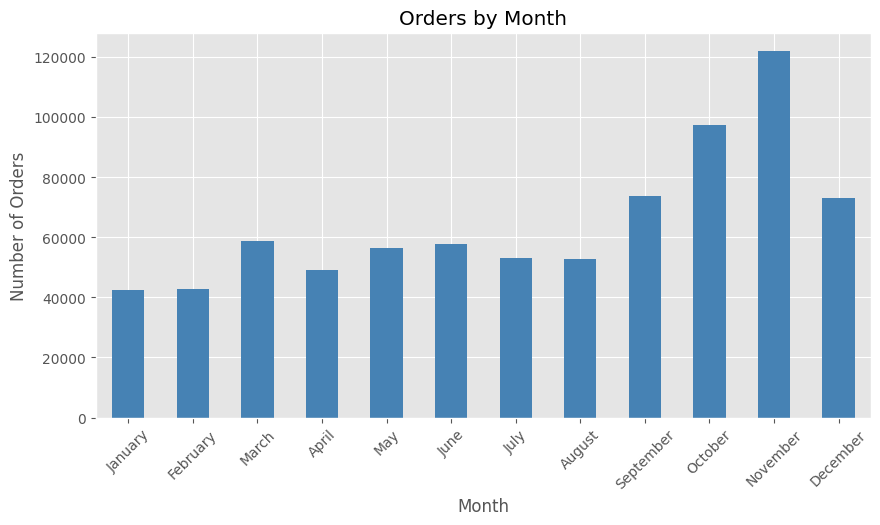

In [24]:
# Orders by Month

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_orders = (
    df.groupby("Month")["Invoice"]
      .count()
      .reindex(month_order)
      .dropna()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

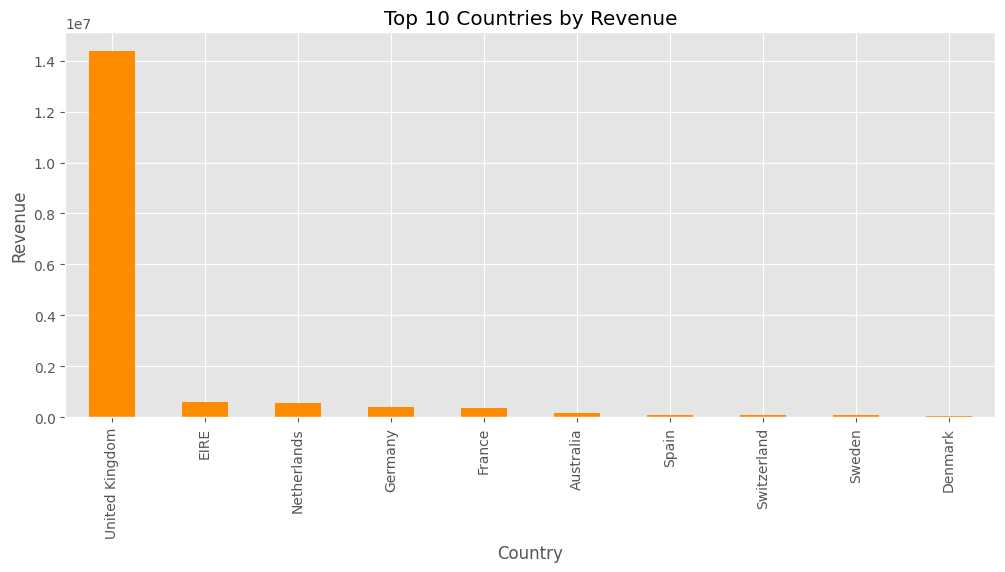

In [25]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

country_sales.plot(kind="bar", color="darkorange")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

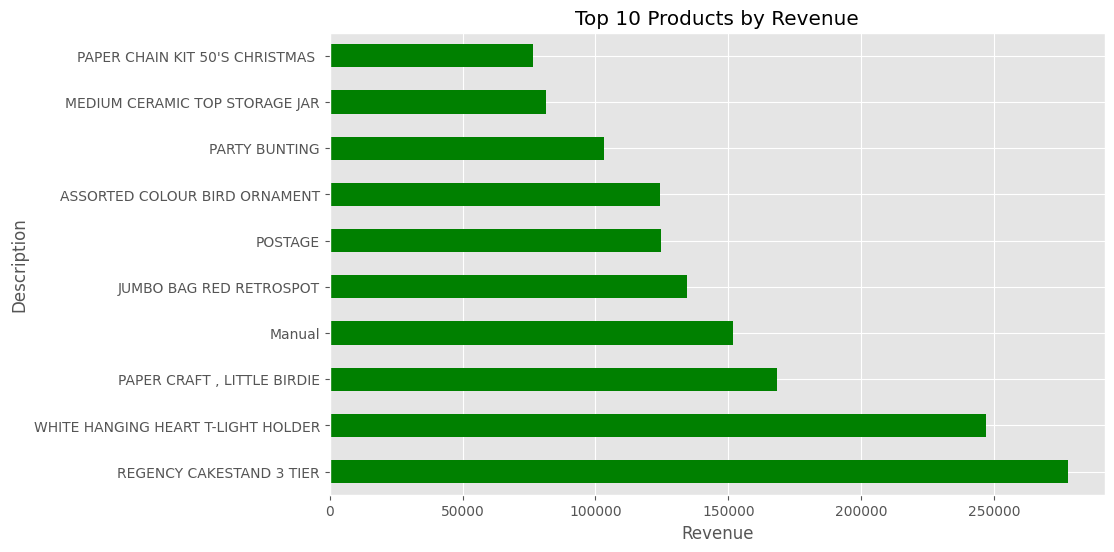

In [26]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_products.plot(kind="barh", color="green")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")

plt.show()

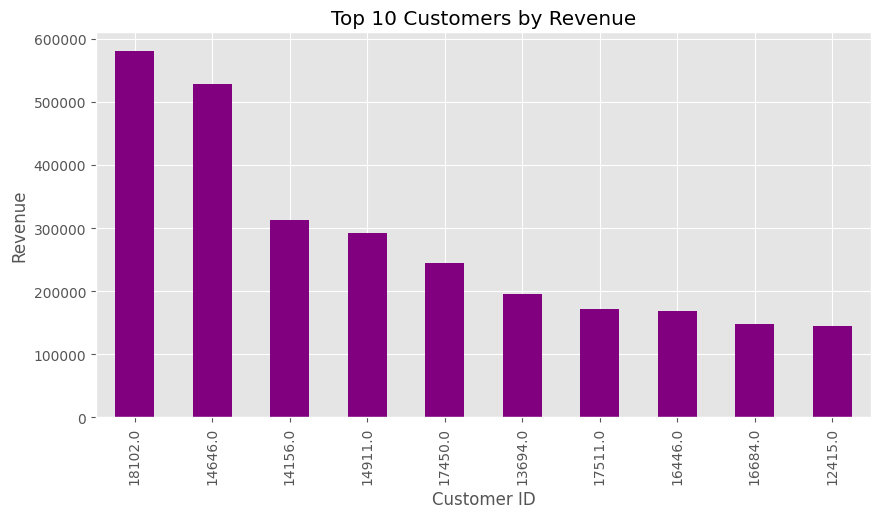

In [27]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_customers.plot(kind="bar", color="purple")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()

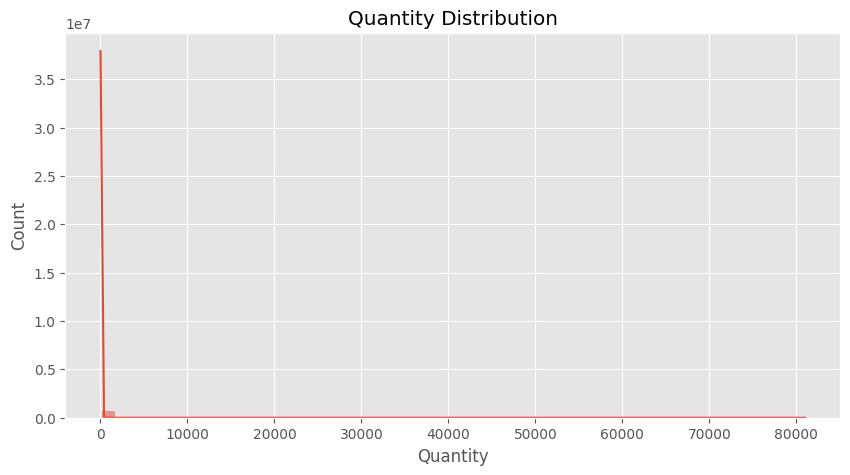

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(df["Quantity"], bins=50, kde=True)

plt.title("Quantity Distribution")

plt.show()

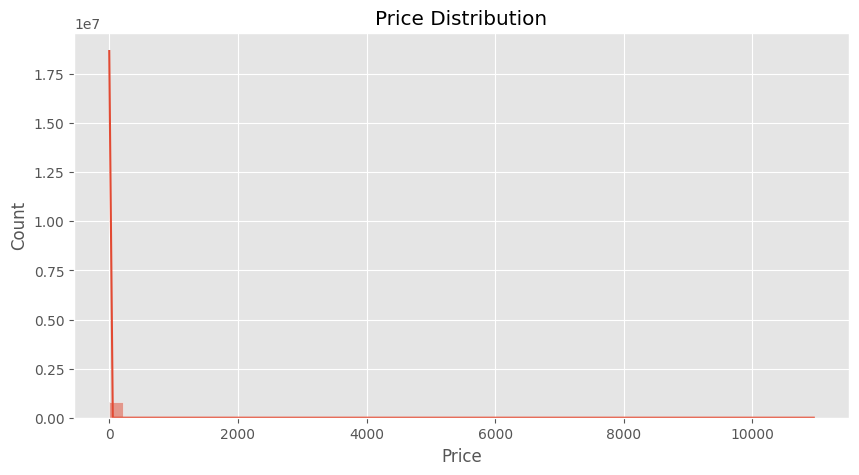

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price"], bins=50, kde=True)

plt.title("Price Distribution")

plt.show()

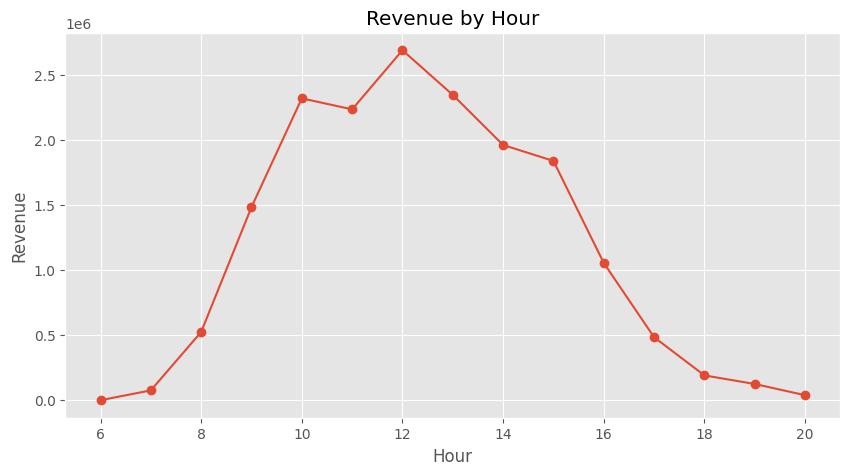

In [30]:
hour_sales = (
    df.groupby("Hour")["Revenue"]
      .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    hour_sales.index,
    hour_sales.values,
    marker="o"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

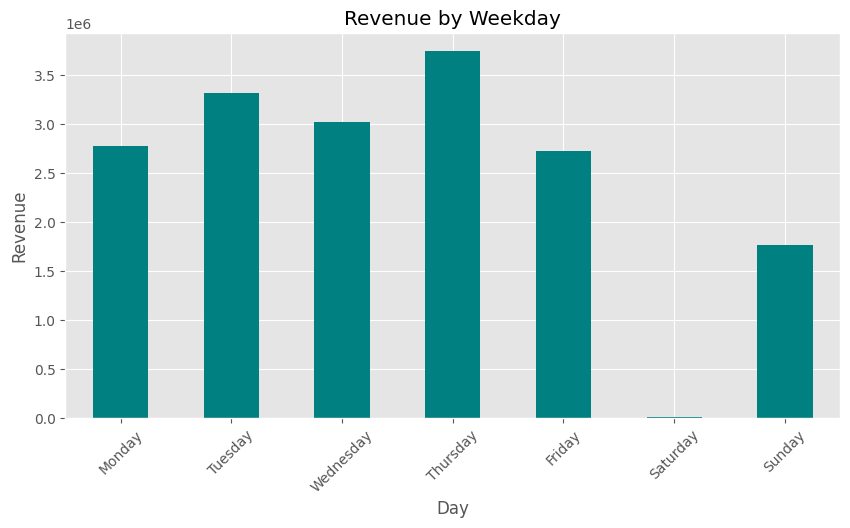

In [31]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df.groupby("Day")["Revenue"]
      .sum()
      .reindex(day_order)
      .dropna()
)

plt.figure(figsize=(10,5))

weekday_sales.plot(
    kind="bar",
    color="teal"
)

plt.title("Revenue by Weekday")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

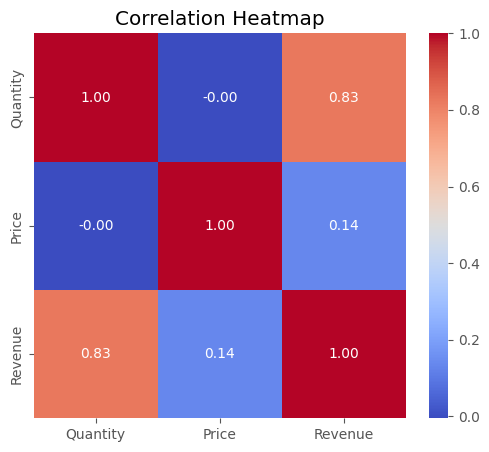

In [32]:
plt.figure(figsize=(6,5))

corr = df[["Quantity", "Price", "Revenue"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

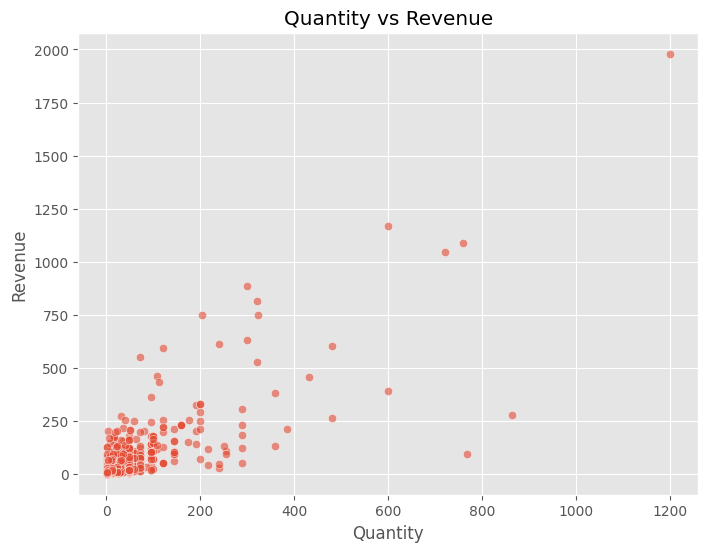

In [33]:
sample = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample,
    x="Quantity",
    y="Revenue",
    alpha=0.6
)

plt.title("Quantity vs Revenue")

plt.show()

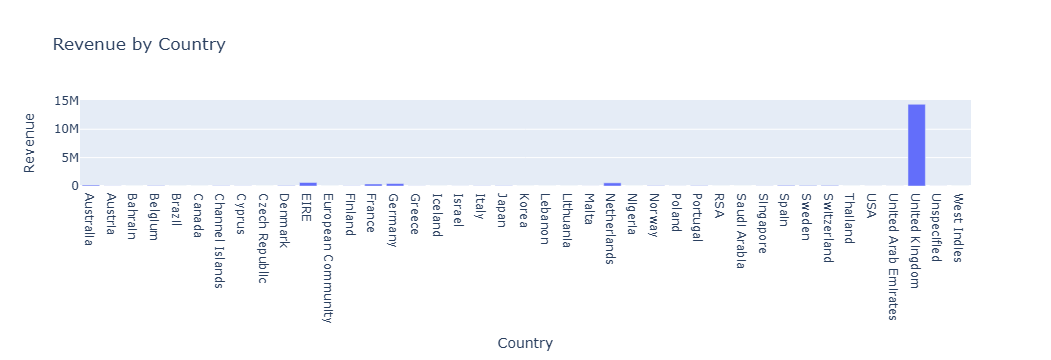

In [34]:
country_df = (
    df.groupby("Country")["Revenue"]
      .sum()
      .reset_index()
)

fig = px.bar(
    country_df,
    x="Country",
    y="Revenue",
    title="Revenue by Country"
)

fig.show()

In [36]:
import sys
!{sys.executable} -m pip install -U nbformat ipykernel

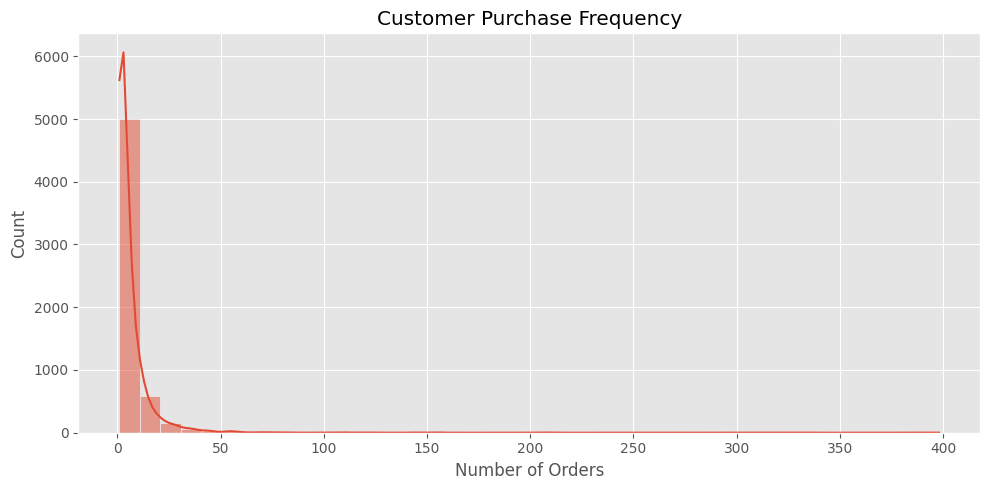

In [37]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

plt.figure(figsize=(10,5))

sns.histplot(
    purchase_frequency,
    bins=40,
    kde=True
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")

plt.tight_layout()
plt.show()

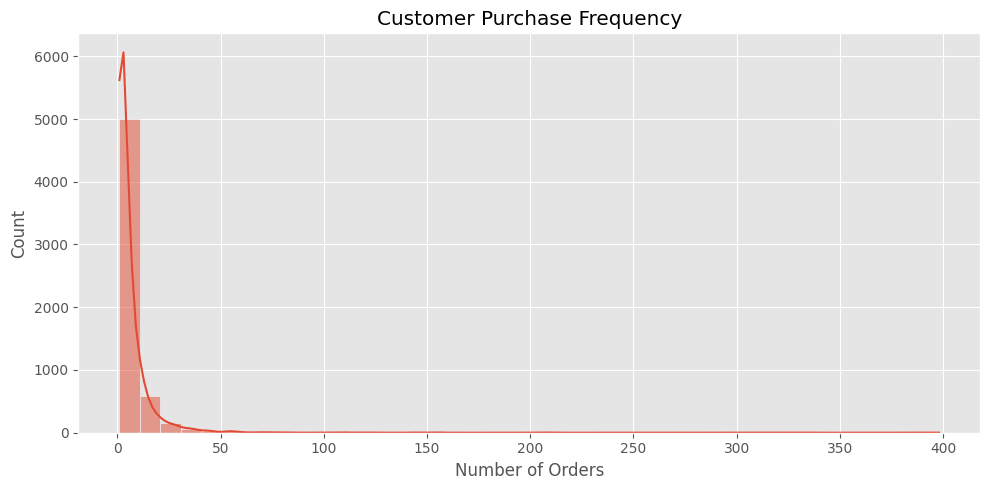

In [38]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

plt.figure(figsize=(10,5))

sns.histplot(
    purchase_frequency,
    bins=40,
    kde=True
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")

plt.tight_layout()
plt.show()

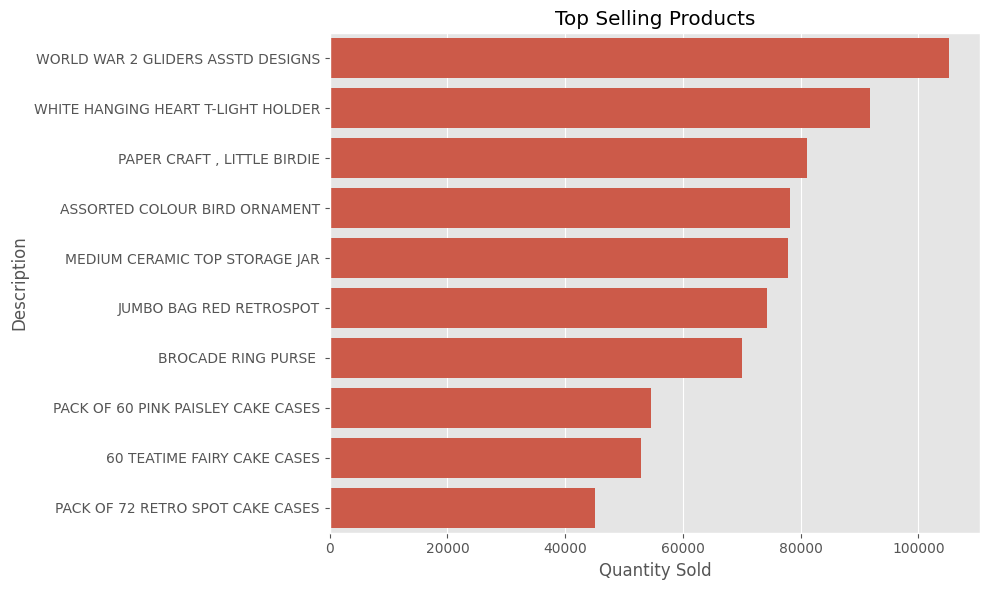

In [39]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_quantity.values,
    y=top_quantity.index
)

plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")

plt.tight_layout()
plt.show()

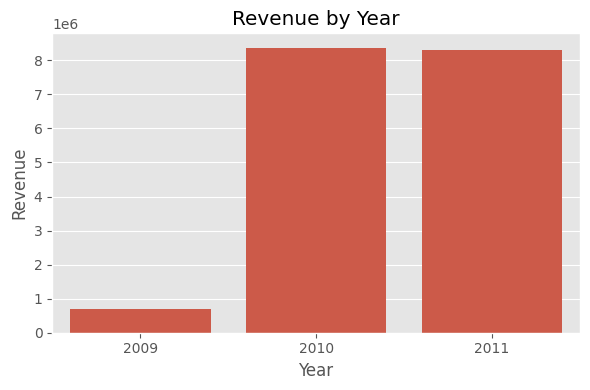

In [40]:
year_sales = (
    df.groupby("Year")["Revenue"]
      .sum()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=year_sales.index.astype(str),
    y=year_sales.values
)

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [41]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Customers",
        "Orders",
        "Products",
        "Countries",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        df["Customer ID"].nunique(),
        df["Invoice"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        avg_order
    ]
})

summary.to_csv("eda_summary.csv", index=False)

summary

,Metric,Value
0,Total Revenue,1.737480e+07
1,Customers,5.878000e+03
2,Orders,3.696900e+04
3,Products,4.631000e+03
4,Countries,4.100000e+01
5,Average Order Value,4.699831e+02


In [42]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("1. The United Kingdom contributes the highest share of revenue.")
print("2. A small number of products generate a large proportion of sales.")
print("3. Customer purchase frequency varies significantly.")
print("4. Peak shopping hours indicate opportunities for targeted marketing.")
print("5. High-value customers contribute disproportionately to revenue.")
print("6. Revenue patterns support customer segmentation strategies.")
print("7. Top-selling products should be prioritized for inventory management.")

BUSINESS INSIGHTS
1. The United Kingdom contributes the highest share of revenue.
2. A small number of products generate a large proportion of sales.
3. Customer purchase frequency varies significantly.
4. Peak shopping hours indicate opportunities for targeted marketing.
5. High-value customers contribute disproportionately to revenue.
6. Revenue patterns support customer segmentation strategies.
7. Top-selling products should be prioritized for inventory management.
